In [3]:
from google.colab import files
uploaded = files.upload()

Saving news_articles.csv to news_articles.csv
Saving news_images.zip to news_images.zip


In [4]:
import zipfile

with zipfile.ZipFile("news_images.zip", 'r') as zip_ref:
    zip_ref.extractall("news_images")

In [5]:

import pandas as pd

df = pd.read_csv("news_articles.csv")

df.head()

,article_id,article_url,article_title,image_id
0,1,https://www.rfdtv.com/helena-agri-enterprises-...,Helena Agri-Enterprises hosts Evolve Innovatio...,2745A43B9E53413E39DFD0B2E52500B1
1,2,https://943wsc.iheart.com/content/2023-07-19-n...,No Evidence Of Toddler On Highway Before Carle...,37FC359AB91C0DC6D21D270AED0C87E3
2,3,https://kowb1290.com/laramie-rangers-play-fina...,Laramie Rangers Play Final Home Games of 2023,59495628A854CBBC399881F38DF6471F
3,4,https://www.mapleridgenews.com/news/undesired-...,'Undesired' air brake release behind B.C. trai...,74921B2C67ED9EA6A509A09FFE2C42DC
4,5,https://www.fourfourtwo.com/news/why-england-c...,Why England CAN win the Women's World Cup 2023...,E10A3861C9122D8704CFE5A6A8343867


In [6]:
import os

image_folder = "news_images/news_images"

def get_image_path(image_id):
    return os.path.join(image_folder, f"{image_id}.jpg")

df["image_path"] = df["image_id"].apply(get_image_path)

df.head()

,article_id,article_url,article_title,image_id,image_path
0,1,https://www.rfdtv.com/helena-agri-enterprises-...,Helena Agri-Enterprises hosts Evolve Innovatio...,2745A43B9E53413E39DFD0B2E52500B1,news_images/news_images/2745A43B9E53413E39DFD0...
1,2,https://943wsc.iheart.com/content/2023-07-19-n...,No Evidence Of Toddler On Highway Before Carle...,37FC359AB91C0DC6D21D270AED0C87E3,news_images/news_images/37FC359AB91C0DC6D21D27...
2,3,https://kowb1290.com/laramie-rangers-play-fina...,Laramie Rangers Play Final Home Games of 2023,59495628A854CBBC399881F38DF6471F,news_images/news_images/59495628A854CBBC399881...
3,4,https://www.mapleridgenews.com/news/undesired-...,'Undesired' air brake release behind B.C. trai...,74921B2C67ED9EA6A509A09FFE2C42DC,news_images/news_images/74921B2C67ED9EA6A509A0...
4,5,https://www.fourfourtwo.com/news/why-england-c...,Why England CAN win the Women's World Cup 2023...,E10A3861C9122D8704CFE5A6A8343867,news_images/news_images/E10A3861C9122D8704CFE5...


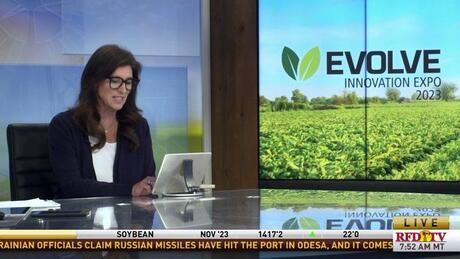

In [7]:
from PIL import Image

img = Image.open(df["image_path"].iloc[0])
img

In [8]:
!pip install transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.4 MB/s eta 0:00:00


In [9]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")

model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16,
    device_map="auto"
)

cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

In [10]:
import torch
from PIL import Image
from tqdm import tqdm
def generate_caption(img_path):
    try:
        image = Image.open(img_path).convert("RGB")

        # prompt = "Describe this image in detail for a news article, including people, setting, and actions."

        inputs = processor(
            images=image,
            # text=prompt,
            return_tensors="pt"
        )

        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=50,
                num_beams=5,
                temperature=0.7
            )

        caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        caption = caption.replace("a photo of", "").strip()

        return caption

    except Exception as e:
        print(f"Error with {img_path}: {e}")
        return ""

tqdm.pandas()

df["caption"] = df["image_path"].progress_apply(generate_caption)

df.to_csv("updated_with_captions.csv", index=False)

print("Done! CSV updated with captions.")

100%|██████████| 8500/8500 [1:26:47<00:00,  1.63it/s]

✅ Done! CSV updated with captions.


In [14]:
files.download("updated_with_captions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>